# Project 1 :- Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
churn_counts = df["Churn"].value_counts()  # target variable

In [11]:
df["TotalCharges"].unique()  # iska type object h, prr wse ye numeric me hona chahiye... to isko convert karenge

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
# errors="coerce" :- Invalid values aur blank spaces ko NaN me convert karne ke liye.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
df.drop("customerID",axis=1,inplace=True)

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

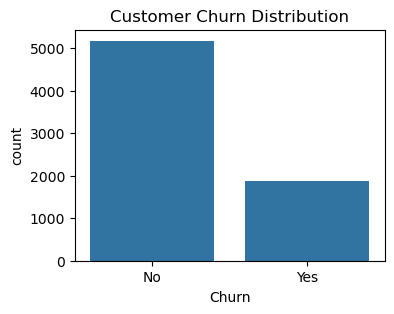

In [20]:
# ye dekhne ke liye ki kitne customers stay kar re h or kitne leave kr rhe h

plt.figure(figsize=(4,3))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

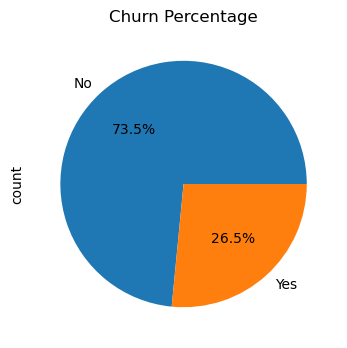

In [21]:
plt.figure(figsize=(5,4))
churn_counts.plot(kind="pie",autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.show()

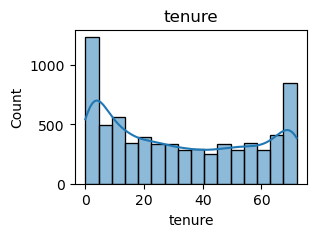

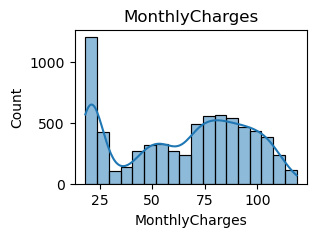

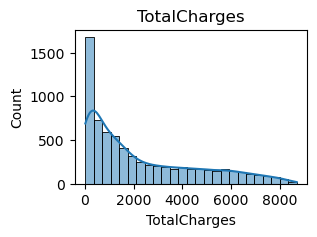

In [22]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
for col in num_cols:
    plt.figure(figsize=(3,2))
    sns.histplot(df[col],kde=True)  # KDE = True kya karta hai? --> Histogram ke upar smooth curve bana deta hai.
    plt.title(col)
    plt.show()

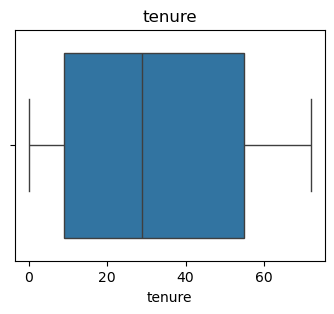

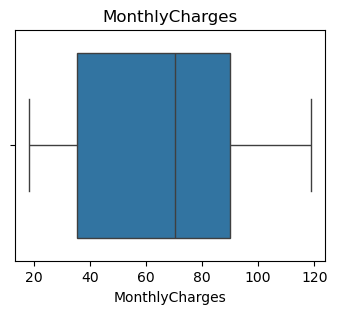

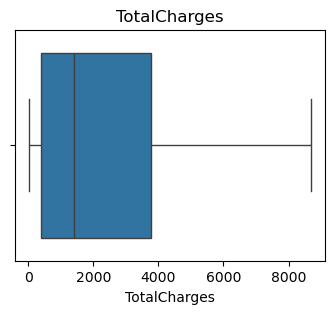

In [23]:
# Extreme values detect karne ke liye.
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

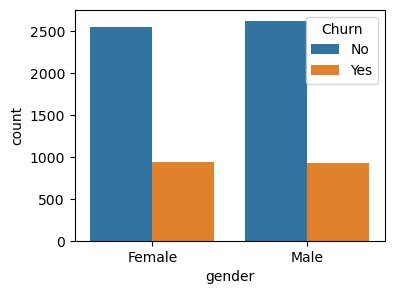

In [24]:
plt.figure(figsize=(4,3))
sns.countplot(x="gender",hue="Churn",data=df)
plt.show()

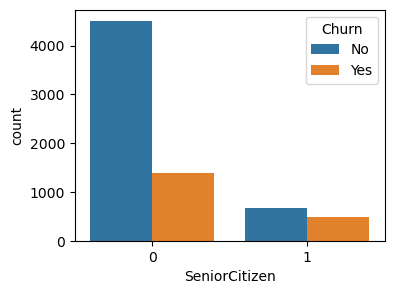

In [25]:
# Senior customers zyada leave kar rahe hain ya nahi.
plt.figure(figsize=(4,3))
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.show()

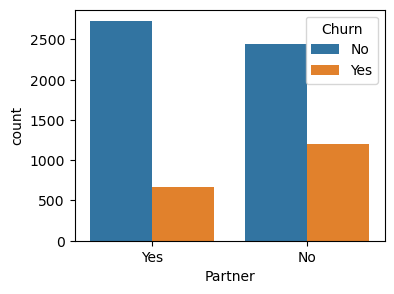

In [26]:
plt.figure(figsize=(4,3))
sns.countplot(x="Partner",hue="Churn",data=df)
plt.show()

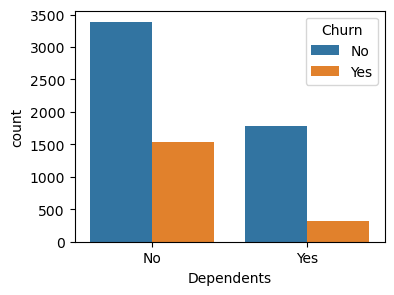

In [27]:
plt.figure(figsize=(4,3))
sns.countplot(x="Dependents",hue="Churn",data=df)
plt.show()

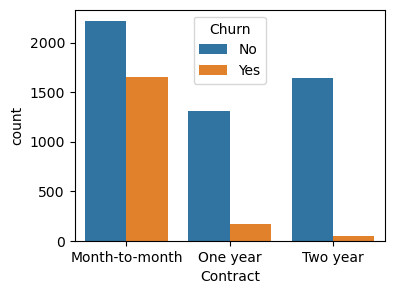

In [28]:
plt.figure(figsize=(4,3))
sns.countplot(x="Contract",hue="Churn",data=df)
plt.show()

# Month-to-month customers churn zyada karte hain.

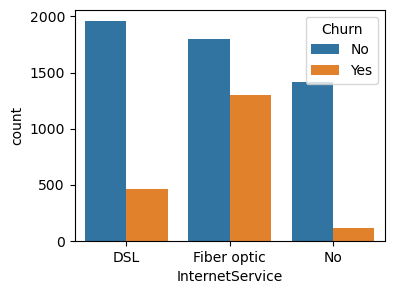

In [29]:
plt.figure(figsize=(4,3))
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.show()

# Fiber customers ka churn high ho sakta hai.

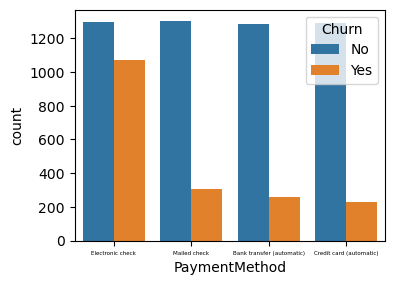

In [30]:
plt.figure(figsize=(4,3))
sns.countplot(x="PaymentMethod",hue="Churn",data=df)
plt.xticks(fontsize=4)
plt.show()

# Kaunsi payment method risky hai.

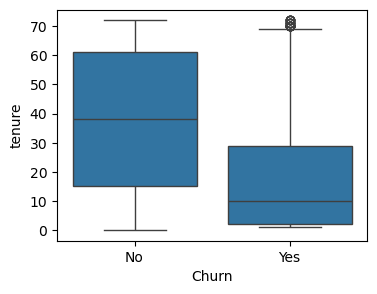

In [31]:
plt.figure(figsize=(4,3))
sns.boxplot(x="Churn",y="tenure",data=df)
plt.show()

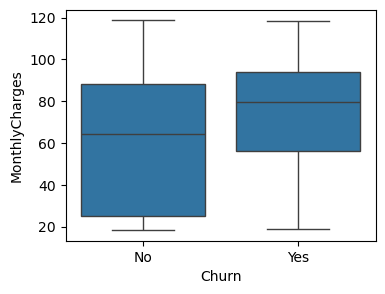

In [32]:
plt.figure(figsize=(4,3))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.show()

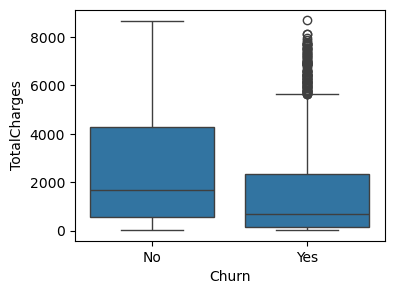

In [33]:
plt.figure(figsize=(4,3))
sns.boxplot(x="Churn",y="TotalCharges",data=df)
plt.show()

# High bill customers leave kar sakte hain.

In [34]:
# Object columns find
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [35]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Correlation Heatmap

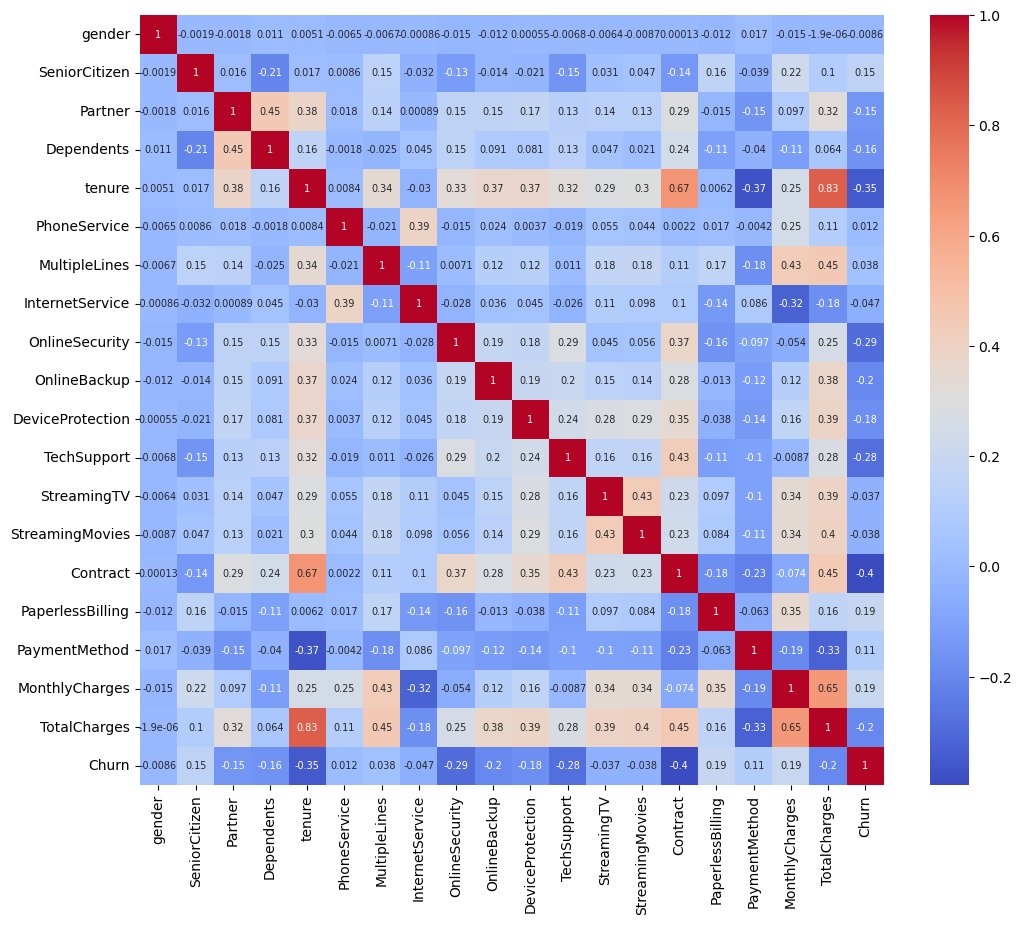

In [36]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",annot_kws={"size":7})
plt.show()

In [37]:
corr = df.corr()["Churn"]
corr.sort_values(ascending=False)  # konse features churn ko sbse jyda effect krte haii

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64

# Feature selection

In [38]:
# Features aur target separate

X = df.drop("Churn", axis=1)
Y = df["Churn"]

In [39]:
from sklearn.model_selection import train_test_split

# Data ko training aur testing me divide karna

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [41]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression

In [42]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, Y_train)
pred_lr = lr.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy 

In [44]:
print("accuracy : ", accuracy_score(Y_test,pred_lr))

accuracy :  0.815471965933286


In [45]:
# Classification report

print(classification_report(Y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



# Confusion Matrix Visualization

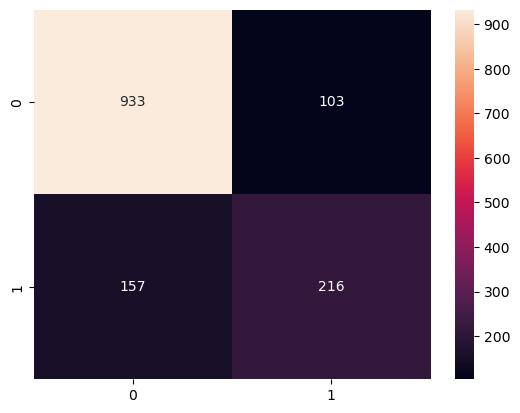

In [46]:
# Confusion Matrix

cm = confusion_matrix(Y_test,pred_lr)
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

# Random Forest Classifier

In [47]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, Y_train)
pred_rf = rf.predict(X_test)

# Accuracy

In [48]:
print("accuracy : ", accuracy_score(Y_test,pred_rf))

accuracy :  0.7963094393186657


In [49]:
# Classification report

print(classification_report(Y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



# Confusion Matrix Visualization

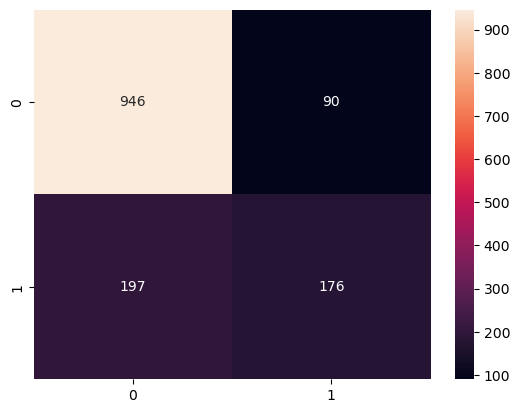

In [50]:
# Confusion Matrix

cm = confusion_matrix(Y_test,pred_rf)
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [51]:
# Business Recommendations :-

# Month-to-month customers ko yearly plan offer karo.

# High monthly charge customers ko discount do.

# New customers ko onboarding support do.

# Tech support improve karo.

# High-risk customers ko retention campaign me add karo.